<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Session_16_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

Q1. Load the dataset and display the first 10 rows

In [ ]:
# Load dataset
df = pd.read_csv("insurance.csv")

# Display first 10 rows
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


Q2. Basic information about the dataset

In [ ]:
# Shape of dataset
print("Shape of Dataset:")
print(df.shape)

print("\nInformation:")
df.info()

print("\nStatistical Summary:")
df.describe()

Shape of Dataset:
(1338, 7)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistical Summary:


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


Q3. Check for missing values

In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


Q4. Identify numerical and categorical columns

In [ ]:
numerical = df.select_dtypes(include=['int64','float64']).columns

categorical = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical)

print("\nCategorical Columns:")
print(categorical)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


Q5. Distribution plots

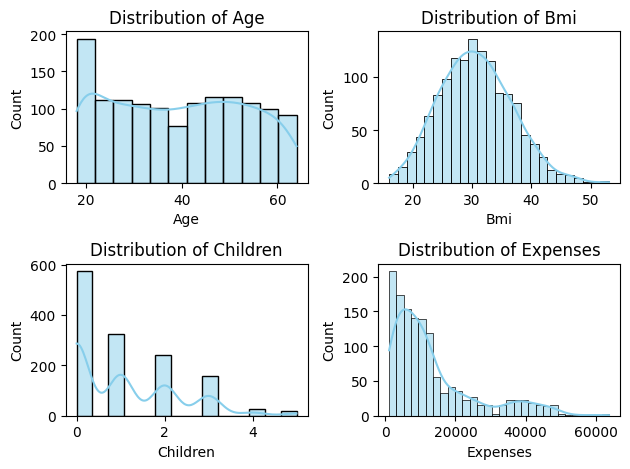

In [ ]:
# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, )

# List of numerical columns
num_cols = ['age', 'bmi', 'children', 'expenses']

# Loop through columns and axes together
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")

# Adjust spacing between plots
plt.tight_layout()

# Display all plots
plt.show()

Q6. Count plots

/tmp/ipykernel_1444/2994778475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_1444/2994778475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Set2')
/tmp/ipykernel_1444/2994778475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Set2')


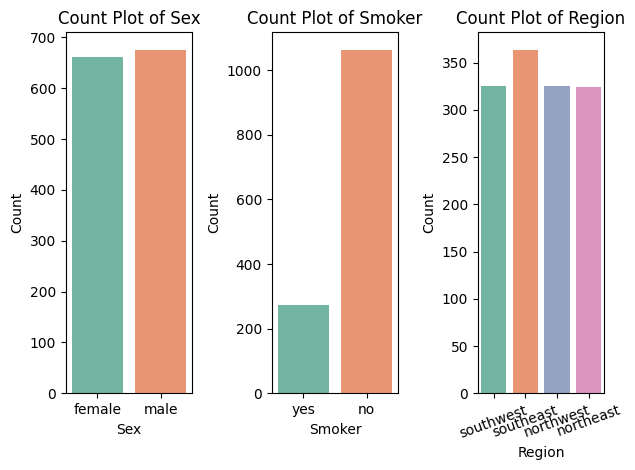

In [ ]:
# Create a 1x3 grid of plots
fig, axes = plt.subplots(1, 3,)

# List of categorical columns
cat_cols = ['sex', 'smoker', 'region']

# Loop through columns and axes
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'Count Plot of {col.capitalize()}')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")

    # Rotate labels only for region
    if col == 'region':
        ax.tick_params(axis='x', rotation=20)

# Adjust spacing
plt.tight_layout()

# Display all plots
plt.show()

Q7. Heatmap

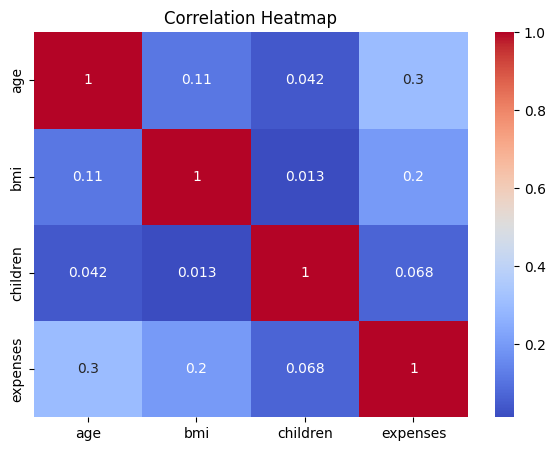

In [ ]:
plt.figure(figsize=(7,5))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Q8. Analysis on Charges

In [ ]:
# Average charges
print("Average Charges:")
print(df['expenses'].mean())

# Maximum charges
print("\nMaximum Charges:")
print(df['expenses'].max())

# Minimum charges
print("\nMinimum Charges:")
print(df['expenses'].min())

# Average charges by smoker
print("\nAverage Charges by Smoker:")
print(df.groupby('smoker')['expenses'].mean())

Average Charges:
13270.422414050823

Maximum Charges:
63770.43

Minimum Charges:
1121.87

Average Charges by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


Q9. Boxplots

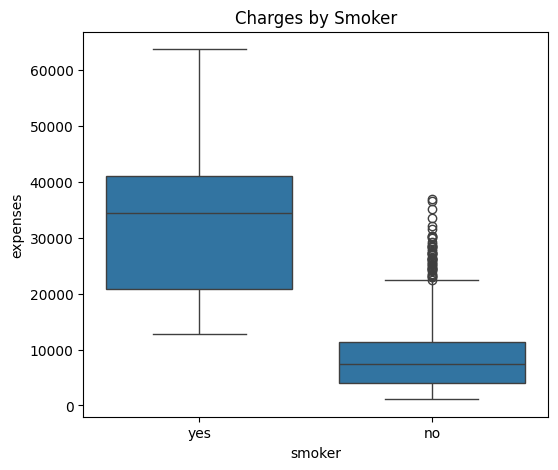

In [ ]:
# Charges vs Smoker

plt.figure(figsize=(6,5))

sns.boxplot(x='smoker',
            y='expenses',
            data=df)

plt.title("Charges by Smoker")

plt.show()

Q10. Analysis Summary

In [ ]:
print("Average Age :", df['age'].mean())
print("Average BMI :", df['bmi'].mean())

print("\nRegion Counts")
print(df['region'].value_counts())

print("\nAverage Charges by Smoker")
print(df.groupby('smoker')['expenses'].mean())

Average Age : 39.20702541106129
Average BMI : 30.66547085201794

Region Counts
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Average Charges by Smoker
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64
